# Notebook 01 — Price Scraping
**Owner:** Shreeyut Neupane

**Research angle:** How has AI-driven hardware demand and market volatility over the last 6 months affected consumer GPU, CPU, and RAM prices — and does Reddit sentiment track or predict those movements?

**Data sources:**
- **Amazon Best Sellers** — one-time scrape to identify the top 10 most purchased CPUs, GPUs, and RAM kits per category (reflects real purchase volume, not benchmark scores)
- **Pangoly.com** — 6 months of price history per product across all available retailers (Newegg, BestBuy, B&H, etc.) via their internal price-chart API

**Pipeline:**
1. **Stage 0 — Product Discovery:** Scrape Amazon Best Sellers (3 requests, run once) → filter out accessories, SODIMM RAM, and off-brand products → `data/prices/amazon_bestsellers.csv`
2. **Stage 1 — Pangoly Matching + UUID Extraction:** Auto-match each Amazon product to its Pangoly slug → fetch product page → extract internal price-chart UUID → `data/prices/products.csv`
3. **Stage 2 — Price History:** Call Pangoly price-chart API per product (`range=180`, last 6 months) → `data/prices/prices_raw.csv`
4. **Stage 3 — Clean:** Aggregate to weekly averages per product per retailer → `data/prices/prices_clean.csv`

**Output:** `data/prices/prices_clean.csv` — columns: `date | product | category | price_usd | retailer | url`

PCPartPicker and CamelCamelCamel were evaluated and ruled out before landing on this approach.

In [24]:
import os, re, time, random
import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd

BASE_URL = "https://pangoly.com"
DATA_DIR = "../data/prices"
os.makedirs(DATA_DIR, exist_ok=True)

# One cloudscraper session shared across Stage 0, 1, and 2
session = cloudscraper.create_scraper(
    browser={"browser": "chrome", "platform": "darwin", "mobile": False}
)


def polite_sleep(min_s=5, max_s=10):
    """Random pause between requests — keeps traffic patterns human-like."""
    t = random.uniform(min_s, max_s)
    print(f"  Waiting {t:.1f}s ...", flush=True)
    time.sleep(t)


print("Setup complete. Session ready.")

Setup complete. Session ready.


## Product Discovery (Amazon Best Sellers)

We scrape the Amazon Best Sellers pages for CPUs, GPUs, and RAM to get the most
purchased hardware products — these are exactly what people discuss on Reddit.

**This stage runs once.** If `amazon_bestsellers.csv` already exists it is skipped,
so you can re-run the whole notebook without hitting Amazon again. To refresh the
list (e.g. in future runs), delete the CSV and re-run this stage.

**Three requests total — one per category, 15–25s apart.**

**Filters applied per category:**
- **GPU** — excludes accessories (sag brackets, risers, cables, GPU stands). Must be a real GPU (RTX / RX / Arc / Radeon).
- **CPU** — excludes contact frames, coolers, thermal paste. Must be a real CPU (Intel Core / AMD Ryzen).
- **RAM** — desktop-only: SODIMM / laptop memory excluded first (260-pin, 262-pin, "Laptop Memory"). Then requires a reputable brand: Corsair, Crucial, G.Skill, Kingston, TeamGroup, Patriot, ADATA, PNY, Samsung.

Filters are keyword and brand-based so they remain valid for future hardware generations.

**Top 10 products per category = 30 total.**

In [25]:
import json

# Amazon Best Sellers URLs 
AMAZON_CATEGORIES = {
    "CPU": "https://www.amazon.com/Best-Sellers-Computer-CPU-Processors/zgbs/pc/229189",
    "GPU": "https://www.amazon.com/Best-Sellers-Computer-Graphics-Cards/zgbs/pc/284822",
    "RAM": "https://www.amazon.com/Best-Sellers-Computer-Memory/zgbs/pc/172500",
}

# Per-category filters
RAM_KNOWN_BRANDS = [
    "corsair", "g.skill", "gskill", "crucial", "kingston fury", "kingston",
    "teamgroup", "team group", "team t-force", "patriot viper", "patriot",
    "adata xpg", "adata", "pny", "samsung", "sk hynix", "thermaltake",
]
# Desktop-only: exclude laptop/SODIMM form factors before checking brand
RAM_EXCLUDE = [
    "sodimm", "so-dimm", "laptop memory", "laptop ram", "notebook memory",
    "260-pin",   # DDR4 SODIMM
    "262-pin",   # DDR5 SODIMM
]
GPU_EXCLUDE = [
    # bare "bracket" removed — GPUs legitimately say "Steel Bracket" (their own PCIe bracket)
    # accessory brackets are caught by the specific phrases below
    "support bar", "holder", "anti-sag", "anti sag", "sag bracket",
    "gpu bracket", "pcie bracket", "brace", "backplate", "thermal pad",
    "riser cable", "pcie riser", "vertical mount", "gpu mount", "stand",
]
GPU_INCLUDE = [
    "rtx", "gtx", "rx 7", "rx 6", "rx 5", "arc a", "arc b",
    "radeon", "geforce", "graphics card",
]
CPU_EXCLUDE = [
    "contact frame", "sealing frame", "socket frame", "cpu frame",
    "lga frame", "am5 frame", "am4 frame", "bracket", "delid", "ihs",
    "thermal compound", "thermal paste", "cpu cooler", "heat sink",
    "heatsink",
]
CPU_INCLUDE = [
    "intel core", "amd ryzen", "amd epyc", "intel xeon", "threadripper",
    "core i3", "core i5", "core i7", "core i9", "core ultra",
    "ryzen 3", "ryzen 5", "ryzen 7", "ryzen 9",
]


def is_valid(name: str, category: str) -> bool:
    n = name.lower()
    if category == "RAM":
        # Exclude laptop/SODIMM first, then require a known desktop brand
        if any(kw in n for kw in RAM_EXCLUDE):
            return False
        return any(brand in n for brand in RAM_KNOWN_BRANDS)
    if category == "GPU":
        # Category page guarantees these are GPUs; only exclude accessories
        return not any(kw in n for kw in GPU_EXCLUDE)
    if category == "CPU":
        # Category page guarantees these are CPUs; only exclude accessories
        return not any(kw in n for kw in CPU_EXCLUDE)
    return True


def parse_bestsellers(html: str, category: str, n: int = 10) -> list[dict]:
    """
    Amazon embeds the ranked ASIN list as JSON in data-client-recs-list on
    div.p13n-desktop-grid. We parse that JSON for rank order, then find each
    product's name from the nearest a[href*='/dp/'] link or span title.
    """
    soup = BeautifulSoup(html, "html.parser")

    # Step 1: get ranked ASINs from the JSON attribute 
    grid = soup.select_one("div[data-client-recs-list]")
    ranked_asins = []  # ordered list of ASINs, index 0 = rank 1
    if grid:
        try:
            recs = json.loads(grid["data-client-recs-list"])
            # Each entry: {"id": "B09FPJL1KY", "metadataMap": {"render.zg.rank": "1", ...}}
            ranked_asins = [
                entry["id"]
                for entry in sorted(recs, key=lambda e: int(e["metadataMap"].get("render.zg.rank", 999)))
                if "id" in entry
            ]
        except Exception as e:
            print(f"    JSON parse error: {e}", flush=True)

    print(f"    ASINs from JSON: {len(ranked_asins)}", flush=True)

    # Step 2: build ASIN → name map from all dp links on the page 
    asin_to_name = {}
    for a in soup.select("a[href*='/dp/']"):
        m = re.search(r"/dp/([A-Z0-9]{10})", a["href"])
        if not m:
            continue
        asin = m.group(1)
        if asin in asin_to_name:
            continue
        # prefer title attr, then aria-label, then span text
        name = (
            a.get("title") or
            a.get("aria-label") or
            a.select_one("span") and a.select_one("span").get_text(strip=True) or
            a.get_text(strip=True)
        )
        if name and len(name) > 5:
            asin_to_name[asin] = name.strip()

    print(f"    ASIN→name mappings found: {len(asin_to_name)}", flush=True)

    # Step 3: walk ranked ASINs, filter, collect up to n
    results = []
    for rank, asin in enumerate(ranked_asins, start=1):
        name = asin_to_name.get(asin)
        if not name:
            continue
        if not is_valid(name, category):
            print(f"    [filtered] {name[:70]}", flush=True)
            continue
        results.append({"rank": rank, "name": name, "category": category})
        if len(results) >= n:
            break

    return results


def scrape_amazon_category(category: str, url: str, n: int = 10) -> list[dict]:
    print(f"  [{category}] GET {url}", flush=True)
    try:
        resp = session.get(url, timeout=40)
    except Exception as e:
        print(f"    Request error: {e}", flush=True)
        return []

    print(f"    HTTP {resp.status_code} | {len(resp.text):,} chars", flush=True)

    if resp.status_code == 403:
        print("    403 — blocked. Do not retry.", flush=True)
        return []
    if resp.status_code in (429, 503):
        print(f"    {resp.status_code} — rate limited. Do not retry.", flush=True)
        return []
    if resp.status_code != 200:
        print(f"    Unexpected status — skipping.", flush=True)
        return []

    products = parse_bestsellers(resp.text, category, n)
    print(f"    → {len(products)} valid products", flush=True)
    return products


print("Stage 0 functions defined.")

Stage 0 functions defined.


In [26]:
# Run Stage 0
# Skipped automatically if amazon_bestsellers.csv already exists.
# To refresh: delete the file and re-run this cell.
bestsellers_path = os.path.join(DATA_DIR, "amazon_bestsellers.csv")

if os.path.exists(bestsellers_path):
    print(f"amazon_bestsellers.csv already exists — skipping Stage 0.")
    print("Delete the file and re-run to refresh the product list.")
else:
    all_products = []
    categories = list(AMAZON_CATEGORIES.items())

    for i, (category, url) in enumerate(categories):
        products = scrape_amazon_category(category, url, n=10)
        all_products.extend(products)

        if i < len(categories) - 1:
            polite_sleep(15, 25)

    if all_products:
        df_bs = pd.DataFrame(all_products)
        df_bs.to_csv(bestsellers_path, index=False)
        print(f"\nSaved {len(df_bs)} products → {bestsellers_path}")
    else:
        print("\nNo products scraped — check your internet connection.")

  [CPU] GET https://www.amazon.com/Best-Sellers-Computer-CPU-Processors/zgbs/pc/229189
    HTTP 200 | 438,570 chars
    ASINs from JSON: 50
    ASIN→name mappings found: 31
    → 10 valid products
  Waiting 16.2s ...
  [GPU] GET https://www.amazon.com/Best-Sellers-Computer-Graphics-Cards/zgbs/pc/284822
    HTTP 200 | 442,282 chars
    ASINs from JSON: 50
    ASIN→name mappings found: 31
    [filtered] Graphics Card GPU Brace Support, Video Card Sag Holder Bracket, GPU St
    [filtered] Uyubao GPU Support Bracket, Gpu Anti Sag Bracket, Graphics Card GPU Br
    → 10 valid products
  Waiting 24.5s ...
  [RAM] GET https://www.amazon.com/Best-Sellers-Computer-Memory/zgbs/pc/172500
    HTTP 200 | 450,436 chars
    ASINs from JSON: 50
    ASIN→name mappings found: 31
    [filtered] Crucial 32GB DDR5 RAM Kit (2x16GB), 5600MHz (or 5200MHz or 4800MHz) La
    [filtered] Crucial 32GB DDR4 RAM Kit (2x16GB), 3200MHz (PC4-25600) CL22 Laptop Me
    [filtered] Timetec 8GB DDR3L / DDR3 1600MHz (DDR3L-16

## Automated Pangoly Matching + UUID Extraction

For each Amazon bestseller we:
1. Build a focused search query (brand + model identifiers)
2. Hit `pangoly.com/en/browse/?q=…` and score results by word overlap with the Amazon name
3. Fetch the best-match product page and extract the internal price-chart UUID
4. Save matched products to `data/prices/products.csv`

Products not found on Pangoly (too new, or not tracked on Newegg) are skipped with a warning.

In [27]:
from urllib.parse import quote as url_quote

PANGOLY_SEARCH  = "https://pangoly.com/en/browse/?q={}"
PANGOLY_HISTORY = "https://pangoly.com/en/price-history/{}"  # UUID lives here
PANGOLY_CHART   = "https://pangoly.com/en/price-chart/{}?st=BestBuy&range={}"

# Pangoly price-chart API returns JSON only with the XMLHttpRequest header (jQuery XHR)
XHR_HEADERS = {"X-Requested-With": "XMLHttpRequest", "Accept": "application/json"}

# Image UUIDs appear under media.pangoly.com — exclude when finding the price-chart UUID
IMAGE_UUID_RE = re.compile(
    r'media\.pangoly\.com/img/[^"]+?([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})'
)
ALL_UUID_RE = re.compile(r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}')

SCORE_STOPWORDS = {
    "the", "a", "an", "in", "with", "for", "and", "or", "of", "to",
    "gaming", "desktop", "processor", "graphics", "card", "memory",
    "ram", "kit", "edition", "series", "unlocked", "computer",
}


def extract_search_query(name: str, category: str) -> str:
    clean = re.sub(r'[™®]', '', name)
    if category == "CPU":
        brand_m = re.match(r'(AMD|Intel)', clean, re.I)
        brand = brand_m.group(0) if brand_m else ""
        m = re.search(r'(ryzen\s+\d+\s+\w+|core\s+i\d+[-\w]+|core\s+ultra\s+\d+[-\w]*)', clean, re.I)
        query = f"{brand} {m.group(0)}".strip() if m else clean.split(",")[0][:50]
        return query
    if category == "GPU":
        brand = clean.split()[0]
        m = re.search(r'(rtx\s+\d+\w*(?:\s+ti)?|rx\s+\d+\w*(?:\s+xt)?|arc\s+[ab]\d+)', clean, re.I)
        vram_m = re.search(r'(\d+)\s*GB', clean, re.I)
        query = f"{brand} {m.group(0)}".strip() if m else clean[:50]
        if vram_m:
            query += f" {vram_m.group(1)}GB"
        return query
    if category == "RAM":
        # Part numbers are unique per SKU — use them directly for an exact Pangoly match.
        # Try parenthesised code at end: (CMH32GX5M2E6000C36), (F4-3200C16D-16GVKB)
        m = re.search(r'\(([A-Z0-9][A-Z0-9\-]{4,})\)\s*$', name)
        if not m:
            # Fallback: trailing code after last dash/en-dash with no parens
            m = re.search(r'[-\u2013]\s*([A-Z0-9][A-Z0-9\-]{4,})\s*$', name)
        if m:
            return m.group(1)
        # Last resort: brand + DDR gen + speed
        brand = clean.split()[0]
        ddr   = re.search(r'ddr[45]', clean, re.I)
        speed = re.search(r'(\d{4,5})\s*mhz', clean, re.I)
        parts = [brand]
        if ddr:   parts.append(ddr.group(0).upper())
        if speed: parts.append(speed.group(1))
        return ' '.join(parts)
    return clean[:60]


def _ram_fallback_query(name: str) -> str:
    """Broader RAM search for when the exact part number returns no Pangoly results.
    Covers variant suffix mismatches e.g. Corsair Z40 (AMD EXPO) vs C40 (Intel XMP)
    — same kit, different SKU ending, only one indexed on Pangoly.
    Uses brand + kit name + DDR gen + speed + total capacity.
    """
    clean = re.sub(r'[™®]', '', name)
    brand = clean.split()[0]
    kit_m  = re.search(r'(vengeance|ripjaws|trident|fury|viper|xpg|t-force|vulcan|royal|dominator)', clean, re.I)
    ddr_m  = re.search(r'(ddr[45])', clean, re.I)
    speed_m = re.search(r'(\d{4,5})\s*mhz', clean, re.I)
    cap_m  = re.search(r'(\d+)\s*gb', clean, re.I)
    parts = [brand]
    if kit_m:   parts.append(kit_m.group(1).capitalize())
    if ddr_m:   parts.append(ddr_m.group(1).upper())
    if speed_m: parts.append(speed_m.group(1))
    if cap_m:   parts.append(f"{cap_m.group(1)}GB")
    return ' '.join(parts)


def score_match(amazon_name: str, pangoly_name: str) -> float:
    def words(s):
        return set(re.sub(r'[^\w\s]', ' ', s.lower()).split()) - SCORE_STOPWORDS
    an, pn = words(amazon_name), words(pangoly_name)
    if not an or not pn:
        return 0.0
    return len(an & pn) / max(len(an), len(pn))


def slug_to_words(slug: str) -> str:
    """Convert a Pangoly slug to space-separated words for scoring.
    e.g. 'amd-ryzen-5-5500' -> 'amd ryzen 5 5500'
    """
    return slug.replace('-', ' ')


def extract_gpu_triple(text: str) -> tuple[str, str, bool]:
    """Extract (model, vram_gb, is_white) from a GPU product name or Pangoly slug.
    model: 'rtx 5060', 'rtx 5060 ti', 'rx 9070 xt', 'arc b580'
    vram:  '8', '16', '12'  (GB digit only, for easy comparison)
    """
    t = re.sub(r'[™®]', '', text).lower().replace('-', ' ')
    model_m = re.search(r'(rtx\s+\d+(?:\s+ti)?|rx\s+\d+(?:\s+xt)?|arc\s+[ab]\d+)', t)
    model = model_m.group(1).strip() if model_m else ''
    vram_m = re.search(r'\b(\d+)gb?\b', t)
    vram = vram_m.group(1) if vram_m else ''
    return model, vram, 'white' in t


def _gpu_slug_matches(slug: str, model: str, vram: str, is_white: bool) -> bool:
    slug_model, slug_vram, slug_is_white = extract_gpu_triple(slug)
    if slug_model and slug_model != model:
        return False
    if vram and slug_vram and slug_vram != vram:
        return False
    # reject white-edition slug for a non-white product (white cards cost more)
    if slug_is_white and not is_white:
        return False
    return True


def _pangoly_search(query: str) -> list[str]:
    """Hit Pangoly browse and return a list of product slugs."""
    try:
        resp = session.get(PANGOLY_SEARCH.format(url_quote(query)), timeout=20)
    except Exception as e:
        print(f"    Search error: {e}", flush=True)
        return []
    if resp.status_code != 200:
        print(f"    Search HTTP {resp.status_code}", flush=True)
        return []
    soup = BeautifulSoup(resp.text, 'html.parser')
    slugs, seen = [], set()
    for link in soup.select('a[href*="/en/product/"]'):
        href = link.get('href', '')
        if '/en/product/' not in href:
            continue
        slug = href.split('/en/product/')[-1].rstrip('/')
        if slug and slug not in seen:
            seen.add(slug)
            slugs.append(slug)
    return slugs


def search_pangoly_slug(product: dict) -> tuple[str | None, str | None]:
    """Search Pangoly browse, return (slug, slug_as_name) or (None, None).
    Scores candidates against the slug (not the displayed text) to avoid the
    rank-badge concatenation bug where e.g. '5500' + '1st' = '55001st' strips
    the model number from the product name.
    For GPUs, hard-filters by (model, VRAM, color) before scoring to prevent
    e.g. RTX 5060 matching 5060 Ti, or TUF matching ROG Astral White.
    For RAM, retries with a broader query when the exact part number misses
    (e.g. Corsair Z40 vs C40 variant suffix difference).
    """
    query = extract_search_query(product['name'], product['category'])
    print(f"    Search query: {query!r}", flush=True)
    slugs = _pangoly_search(query)

    # RAM fallback: part number had no match — retry with brand+kit+speed+capacity
    if not slugs and product['category'] == 'RAM':
        fallback = _ram_fallback_query(product['name'])
        print(f"    Part number miss — retrying: {fallback!r}", flush=True)
        slugs = _pangoly_search(fallback)

    if not slugs:
        print('    No Pangoly results', flush=True)
        return None, None

    # GPU hard-filter: exact model + VRAM + reject white for non-white products
    if product['category'] == 'GPU':
        amazon_model, amazon_vram, amazon_is_white = extract_gpu_triple(product['name'])
        if amazon_model:
            filtered = [s for s in slugs if _gpu_slug_matches(s, amazon_model, amazon_vram, amazon_is_white)]
            if filtered:
                slugs = filtered
            else:
                print(f"    WARNING: GPU hard-filter removed all candidates — falling back to unfiltered", flush=True)

    # Score by matching Amazon name against slug words — avoids rank-badge corruption
    scored = sorted(
        [(score_match(product['name'], slug_to_words(slug)), slug) for slug in slugs],
        reverse=True,
    )
    best_score, best_slug = scored[0]
    print(f"    Best match ({best_score:.2f}): {best_slug}", flush=True)
    if best_score < 0.15:
        print('    Score too low — skipping', flush=True)
        return None, None
    return best_slug, best_slug


def fetch_uuid(slug: str) -> str | None:
    """
    Fetch the Pangoly price-history page and extract the price-chart UUID.
    The UUID is in the page HTML, distinct from image UUIDs (media.pangoly.com).
    """
    url = PANGOLY_HISTORY.format(slug)
    try:
        resp = session.get(url, timeout=30)
    except Exception as e:
        print(f"    UUID fetch error: {e}", flush=True)
        return None
    if resp.status_code != 200:
        print(f"    UUID fetch HTTP {resp.status_code}", flush=True)
        return None

    image_uuids = set(IMAGE_UUID_RE.findall(resp.text))
    all_uuids   = dict.fromkeys(ALL_UUID_RE.findall(resp.text))
    price_uuids = [u for u in all_uuids if u not in image_uuids]

    if not price_uuids:
        print('    No price-chart UUID on page (product may not have Newegg/BestBuy history)', flush=True)
        return None

    uuid = price_uuids[0]
    print(f"    UUID: {uuid}", flush=True)
    return uuid


print('Stage 1 functions defined.')

Stage 1 functions defined.


In [29]:
# ── Run Stage 1 ───────────────────────────────────────────────────────────────
products_path = os.path.join(DATA_DIR, "products.csv")

if os.path.exists(products_path):
    print(f"products.csv already exists — skipping Stage 1.")
    print("Delete the file and re-run to refresh.")
else:
    df_bs = pd.read_csv(os.path.join(DATA_DIR, "amazon_bestsellers.csv"))
    matched = []

    for _, row in df_bs.iterrows():
        product = row.to_dict()
        print(f"\n[{product['category']}] {product['name'][:60]}", flush=True)

        slug, pangoly_name = search_pangoly_slug(product)
        if not slug:
            print(f"    ✗ No Pangoly match — skipping", flush=True)
            polite_sleep(3, 6)
            continue

        polite_sleep(3, 6)

        uuid = fetch_uuid(slug)
        if not uuid:
            print(f"    ✗ No price-chart UUID — skipping", flush=True)
            polite_sleep(3, 6)
            continue

        matched.append({
            "name":         product["name"],
            "category":     product["category"],
            "pangoly_name": pangoly_name,
            "slug":         slug,
            "uuid":         uuid,
            "url":          f"{BASE_URL}/en/product/{slug}",
        })
        print(f"    ✓ {slug}", flush=True)
        polite_sleep(3, 6)

    df_products = pd.DataFrame(matched)
    df_products.to_csv(products_path, index=False)
    print(f"\nMatched {len(df_products)} / {len(df_bs)} products → {products_path}")

products.csv already exists — skipping Stage 1.
Delete the file and re-run to refresh.


## Stage 2 — Price History

We call the Pangoly internal price-chart endpoint directly — the same endpoint the
browser uses to populate the Flot.js chart. Discovered via Chrome DevTools Network tab.

**Endpoint:** `https://pangoly.com/en/price-chart/{uuid}?st=BestBuy&range=180`

**Response format:**
```json
{
  "Newegg": [
    [1711929600000.0, 309.99],
    [1712016000000.0, 305.99],
    ...
  ],
  "BestBuy": [...]
}
```
Each entry is `[unix_milliseconds, price_usd]`. `range=180` gives the last 6 months of data.
All available retailers are returned — Newegg, BestBuy, B&H Photo, Walmart, etc.

One API call per product. Same `cloudscraper` session from Stage 1 (already past Cloudflare).
5–10s sleep between requests.

In [30]:
def fetch_price_history(uuid: str, range_days: int = 180) -> dict:
    """
    Call the Pangoly price-chart API for a single product.
    range_days=180 → last 6 months of data.
    Requires XHR headers — the endpoint returns JSON only to jQuery XHR calls.
    """
    url = PANGOLY_CHART.format(uuid, range_days)
    try:
        resp = session.get(url, headers=XHR_HEADERS, timeout=30)
    except Exception as e:
        print(f"    Request error: {e}", flush=True)
        return {}
    if resp.status_code == 403:
        print('    403 — blocked. Do not retry.', flush=True)
        return {}
    if resp.status_code == 429:
        print('    429 — rate limited. Do not retry.', flush=True)
        return {}
    if resp.status_code != 200:
        print(f"    Got {resp.status_code} — skipping.", flush=True)
        return {}
    try:
        return resp.json()
    except Exception as e:
        print(f"    JSON parse error: {e}", flush=True)
        return {}


def parse_price_data(price_json: dict, product: dict) -> list[dict]:
    """
    Flatten Pangoly price-chart JSON into daily price records.
    JSON: {"BestBuy": [[unix_ms, price], ...], "Newegg": [...], ...}
    """
    records = []
    for retailer, data_points in price_json.items():
        for point in data_points:
            if not (isinstance(point, list) and len(point) == 2):
                continue
            unix_ms, price = point
            if price is None or price <= 0:
                continue
            records.append({
                'date':      pd.to_datetime(unix_ms, unit='ms').strftime('%Y-%m-%d'),
                'product':   product['name'],
                'category':  product['category'],
                'price_usd': round(float(price), 2),
                'retailer':  retailer,
                'url':       product['url'],
            })
    return records


print('Stage 2 functions defined.')


Stage 2 functions defined.


In [31]:
# ── Run Stage 2 ──────────────────────────────────────────────────────────────
# Reuse the session from Stage 1 (already past Cloudflare).
# If running this cell standalone, recreate the session and reload products.
if "session" not in dir():
    session = cloudscraper.create_scraper(
        browser={"browser": "chrome", "platform": "darwin", "mobile": False}
    )
if "df_products" not in dir() or df_products.empty:
    df_products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"))

raw_records = []

for i, row in df_products.iterrows():
    product = row.to_dict()
    print(f"  {product['name'][:70]}", flush=True)

    price_json = fetch_price_history(product["uuid"])

    if not price_json:
        print("    WARNING: no price data returned — skipping.", flush=True)
    else:
        records = parse_price_data(price_json, product)
        raw_records.extend(records)
        print(f"    {len(records)} price records", flush=True)

    if i < len(df_products) - 1:
        polite_sleep()

df_raw = pd.DataFrame(raw_records)
raw_path = os.path.join(DATA_DIR, "prices_raw.csv")
df_raw.to_csv(raw_path, index=False)

print(f"\nSaved {len(df_raw)} raw records → {raw_path}")
df_raw.head()

  AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop Processor
    743 price records
  Waiting 5.9s ...
  AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked Desktop Processor with Wra
    544 price records
  Waiting 8.5s ...
  AMD Ryzen™ 5 9600X 6-Core, 12-Thread Unlocked Desktop Processor
    602 price records
  Waiting 8.7s ...
  AMD Ryzen 7 7800X3D 8-Core, 16-Thread Desktop Processor
    655 price records
  Waiting 10.0s ...
  AMD Ryzen 9 9950X3D 16-Core Processor
    556 price records
  Waiting 7.9s ...
  AMD Ryzen™ 7 5800XT 8-Core, 16-Thread Unlocked Desktop Processor
    550 price records
  Waiting 9.2s ...
  AMD Ryzen 5 5600 6-Core, 12-Thread Unlocked Desktop Processor with Wra
    437 price records
  Waiting 8.1s ...
  AMD Ryzen 5 7600X 6-Core, 12-Thread Unlocked Desktop Processor
    727 price records
  Waiting 9.7s ...
  AMD Ryzen™ 7 9700X 8-Core, 16-Thread Unlocked Desktop Processor
    721 price records
  Waiting 7.9s ...
  AMD Ryzen™ 9 9900X 12-Core, 24-Thread Unlocked Desktop Process

,date,product,category,price_usd,retailer,url
0,2025-10-16,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.0,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...
1,2025-10-17,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.0,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...
2,2025-10-18,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.0,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...
3,2025-10-19,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.0,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...
4,2025-10-20,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.0,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...


## Stage 3 — Clean
Aggregate raw daily records to **weekly averages** per product.
Output columns match the spec expected by Notebook 04: `date | product | category | price_usd | retailer | url`

In [32]:
# ── Run Stage 3 ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(os.path.join(DATA_DIR, "prices_raw.csv"), parse_dates=["date"])

df_raw["week"] = df_raw["date"].dt.to_period("W")

df_clean = (
    df_raw
    .groupby(["week", "product", "category", "retailer", "url"], as_index=False)["price_usd"]
    .mean()
)
df_clean["price_usd"] = df_clean["price_usd"].round(2)

# Convert Period to Monday start date — Notebook 04 expects a parseable date column
df_clean["date"] = df_clean["week"].apply(lambda p: p.start_time.strftime("%Y-%m-%d"))
df_clean = df_clean.drop(columns=["week"])[
    ["date", "product", "category", "price_usd", "retailer", "url"]
]

clean_path = os.path.join(DATA_DIR, "prices_clean.csv")
df_clean.to_csv(clean_path, index=False)

print(f"Saved {len(df_clean)} weekly records → {clean_path}")
df_clean.head(20)

Saved 2352 weekly records → ../data/prices/prices_clean.csv


,date,product,category,price_usd,retailer,url
0,2025-10-13,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.00,Abt Electronics,https://pangoly.com/en/product/amd-ryzen-7-980...
1,2025-10-13,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,459.98,B&H Photo Video,https://pangoly.com/en/product/amd-ryzen-7-980...
2,2025-10-13,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.00,BestBuy,https://pangoly.com/en/product/amd-ryzen-7-980...
3,2025-10-13,"AMD RYZEN 7 9800X3D 8-Core, 16-Thread Desktop ...",CPU,479.00,Newegg,https://pangoly.com/en/product/amd-ryzen-7-980...
4,2025-10-13,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,75.00,B&H Photo Video,https://pangoly.com/en/product/amd-ryzen-5-5500
5,2025-10-13,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,115.93,BestBuy,https://pangoly.com/en/product/amd-ryzen-5-5500
6,2025-10-13,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,85.75,Newegg,https://pangoly.com/en/product/amd-ryzen-5-5500
7,2025-10-13,"AMD Ryzen 5 5600 6-Core, 12-Thread Unlocked De...",CPU,194.99,B&H Photo Video,https://pangoly.com/en/product/amd-ryzen-5-5600
8,2025-10-13,"AMD Ryzen 5 5600 6-Core, 12-Thread Unlocked De...",CPU,130.74,Newegg Sellers,https://pangoly.com/en/product/amd-ryzen-5-5600
9,2025-10-13,"AMD Ryzen 5 7600X 6-Core, 12-Thread Unlocked D...",CPU,189.99,B&H Photo Video,https://pangoly.com/en/product/amd-ryzen-5-7600x


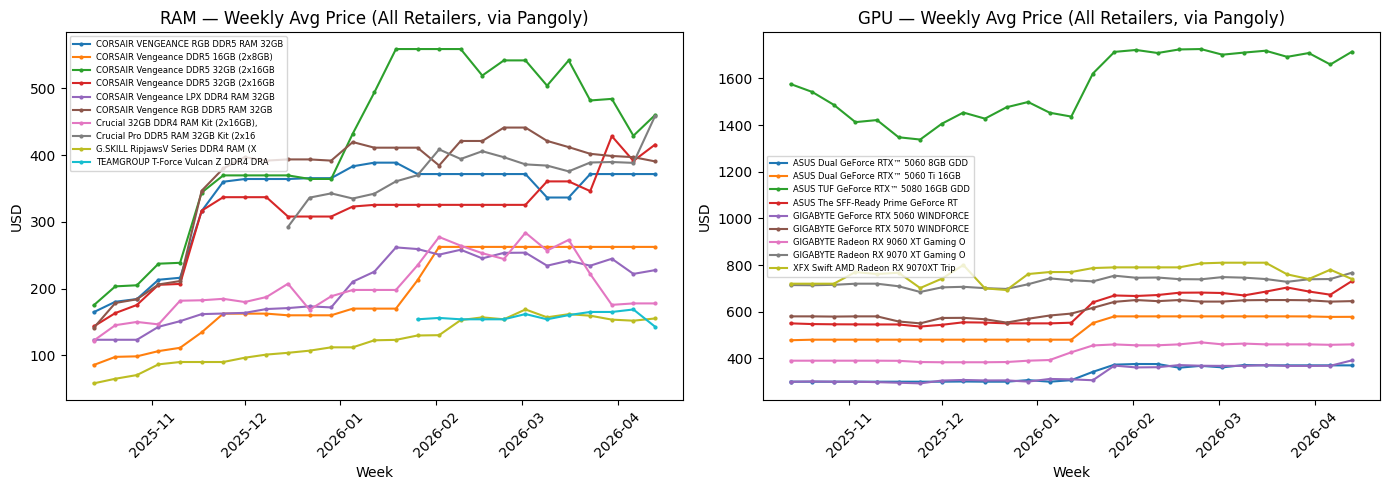

Plot saved.


In [33]:
import matplotlib.pyplot as plt

df_plot = pd.read_csv(os.path.join(DATA_DIR, "prices_clean.csv"), parse_dates=["date"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cat in zip(axes, ["RAM", "GPU"]):
    subset = df_plot[df_plot["category"] == cat]
    for name, grp in subset.groupby("product"):
        weekly = grp.groupby("date")["price_usd"].mean().reset_index()
        ax.plot(weekly["date"], weekly["price_usd"],
                marker="o", markersize=2, label=name[:35])
    ax.set_title(f"{cat} — Weekly Avg Price (All Retailers, via Pangoly)")
    ax.set_xlabel("Week")
    ax.set_ylabel("USD")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "price_trends.png"), dpi=120)
plt.show()
print("Plot saved.")